In [9]:
import cv2
%load_ext autoreload
%autoreload 2

In [10]:

from libs.tool_opencv import *



In [11]:
"images/nova_familia.jpg"
path = "/home/guilherme/py_projects/computer-vision/data/eu.jpeg"
image = cv2.imread(path)

get_info_image(image)

# show_image(image)

Altura: 800 pixels
Largura: 800 pixels
Canais: 3


In [6]:
# Imagens são simplesmente arrays NumPy. Um pixel no canto superior esquerdo pode ser encontrado como (0, 0)
(b, g, r) = image[0, 0]
print("Pixel em (0, 0) - Red: {}, Green: {}, Blue: {}".format(r, g, b))


# Agora mudamos o valor do pixel
image[0, 0] = (0, 0, 255)
(b, g, r) = image[0, 0]
print("Pixel em (0, 0) - Red: {}, Green: {}, Blue: {}".format(r, g, b))

Pixel em (0, 0) - Red: 154, Green: 117, Blue: 73
Pixel em (0, 0) - Red: 255, Green: 0, Blue: 0


In [7]:
# Como estamos usando matrizes numPy, podemos aplicar slicing e obter grandes pedaços da imagem. 
# Vamos pegar a parte superior esquerda
corner = image[0:100, 0:100]
show_image(corner)

In [8]:
# Mudamos o canto superior esquerdo para verde
image[0:100, 0:100] = (0, 255, 0)
show_image(image)

### opencv-drawing

In [ ]:
# Desenhando com o OpenCV

# Imports
import numpy as np
import cv2

# Inicializando nossa tela como um 300x300 com 3 canais, Vermelho, Verde e Azul, com um fundo preto
canvas = np.zeros((300, 300, 3), dtype = "uint8")

# Desenhando uma linha verde do canto superior esquerdo da nossa tela para o canto inferior direito
green = (0, 255, 0)
cv2.line(canvas, (0, 0), (300, 300), green)
cv2.imshow("Canvas", canvas)
cv2.waitKey(0)

# Agora, desenhamos uma linha vermelha de 3 pixels de espessura do canto superior direito para a parte inferior esquerda
red = (0, 0, 255)
cv2.line(canvas, (300, 0), (0, 300), red, 3)
cv2.imshow("Canvas", canvas)
cv2.waitKey(0)

# Desenhamos um quadrado verde de 50x50 pixels, começando em 10x10 e que termina em 60x60
cv2.rectangle(canvas, (10, 10), (60, 60), green)
cv2.imshow("Canvas", canvas)
cv2.waitKey(0)

# Desenhamos outro retângulo, desta vez vamos torná-lo vermelho e 5 pixels de espessura
cv2.rectangle(canvas, (50, 200), (200, 225), red, 5)
cv2.imshow("Canvas", canvas)
cv2.waitKey(0)

# Vamos desenhar um último retângulo: azul e preenchido
blue = (255, 0, 0)
cv2.rectangle(canvas, (200, 50), (225, 125), blue, -1)
cv2.imshow("Canvas", canvas)
cv2.waitKey(0)

# Reset da nossa tela e desenheando um círculo branco no centro da tela com raios crescentes - de 25 pixels para 150 pixels
canvas = np.zeros((300, 300, 3), dtype = "uint8")
(centerX, centerY) = (canvas.shape[1] // 2, canvas.shape[0] // 2)
white = (255, 255, 255)

for r in range(0, 175, 25):
	cv2.circle(canvas, (centerX, centerY), r, white)

cv2.imshow("Canvas", canvas)
cv2.waitKey(0)

# Desenhando 25 círculos
for i in range(0, 25):
	# Gerando aleatoriamente um tamanho de raio entre 5 e 200.
	# Gerando uma cor aleatória e, em seguida.
	radius = np.random.randint(5, high = 200)
	color = np.random.randint(0, high = 256, size = (3,)).tolist()
	pt = np.random.randint(0, high = 300, size = (2,))

	# Desenhando o círculo
	cv2.circle(canvas, tuple(pt), radius, color, -1)

# Visualizando o resultado
cv2.imshow("Canvas", canvas)
cv2.waitKey(0)


import cv2 

imagem = cv2.imread('images/estrada.jpg') 

for y in range(0, imagem.shape[0], 10): #percorre linhas
	for x in range(0, imagem.shape[1], 10): #percorre colunas
		imagem[y:y+5, x: x+5] = (0,255,255)

cv2.imshow("Imagem modificada", imagem) 
cv2.waitKey(0)


# Gravando texto na imagem

# Imports
import numpy as np
import argparse
import cv2

# Argumentos
ap = argparse.ArgumentParser()
ap.add_argument("-i", "--image", required = True, help = "Caminho para a imagem")
args = vars(ap.parse_args())

# Carregando a imagem
image = cv2.imread(args["image"])

# Gravando texto na imagem
fonte = cv2.FONT_HERSHEY_SIMPLEX 
cv2.putText(image,'Estrada',(15,65), fonte, 2,(255,255,255),2,cv2.LINE_AA)

# Mostra a imagem
cv2.imshow("Estrada", image) 
cv2.waitKey(0)

Numeric mode unsupported in the posix collation implementation


### opencv-shift

In [13]:
import numpy as np
from libs import utils

# Shifting de uma imagem é dada por uma matriz NumPy na forma:
#	[[1, 0, shiftX], [0, 1, shiftY]]

# Você simplesmente precisa especificar quantos pixels você deseja para mudar a imagem nas direções X e Y.
# Vamos fazer o shift da imagem 25 pixels para a direita e 50 pixels para baixo.
M = np.float32([[1, 0, 25], [0, 1, 50]])
shifted = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
show_image(shifted, "Shift para baixo e para direita")


# Agora, vamos mudar a imagem 50 pixels para a esquerda e 90 pixels para cima. 
# Realizamos isso usando valores negativos.
M = np.float32([[1, 0, -50], [0, 1, -90]])
shifted = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
show_image(shifted, "Shift para baixo e para esquerda")


# Finalmente, vamos usar nossa função auxiliar em utils.py para deslocar a imagem para baixo 100 pixels.
shifted = utils.translate(image, 0, 100)
cv2.imshow("Shift para baixo", shifted)
show_image(shifted, "Shift para baixo")


### opencv-rotation

In [15]:
# Obtém as dimensões da imagem e calcule o centro da imagem
(h, w) = image.shape[:2]
center = (w // 2, h // 2)

# Rotaciona a imagem em 45 graus
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(image, M, (w, h))
show_image(rotated, "Rotacionado em 45 graus")

# Rotaciona a imagem em 90 graus
M = cv2.getRotationMatrix2D(center, -90, 1.0)
rotated = cv2.warpAffine(image, M, (w, h))
show_image(rotated, "Rotacionado em 90 graus")

# Finalmente, vamos usar nossa função auxiliar em utils.py para girar a imagem em 180 graus 
rotated = utils.rotate(image, 180)
show_image(rotated, "Rotacionado em 180 graus")

### opencv-resize

In [ ]:
# Precisamos ter em mente o "aspect ratio" para que a imagem não pareça distorcida.
# Portanto, calculamos a proporção da nova imagem para a imagem antiga. 
# Vamos fazer a nossa nova imagem ter uma largura de 150 pixels
r = 150.0 / image.shape[1]
dim = (150, int(image.shape[0] * r))

# Execute o redimensionamento real da imagem
resized = cv2.resize(image, dim, interpolation = cv2.INTER_AREA)
show_image(resized, "Redimensionada (Largura)")

# E se quisermos ajustar a altura da imagem? 
# Aplicamos o mesmo conceito, novamente tendo em mente a relação de aspecto, mas calculando a relação com base na altura.
# Vamos fazer a altura da imagem redimensionada 50 pixels
r = 50.0 / image.shape[0]
dim = (int(image.shape[1] * r), 50)

# Execute o redimensionamento
resized = cv2.resize(image, dim, interpolation = cv2.INTER_AREA)
show_image(resized, "Redimensionada (Altura)")

# Claro, calcular a razão cada vez que queremos redimensionar uma imagem é uma dor real. 
# Vamos criar uma função onde podemos especificar nossa largura ou altura alvo, e ter cuidado com o resto para nós.
resized = utils.resize(image, width = 100)
show_image(resized, "Redimensionada via Função")

### opencv-flipping

In [19]:

# Flip horizontal
flipped = cv2.flip(image, 1)
utils.imshow("Flip horizontal", flipped)

# Flip vertical
flipped = cv2.flip(image, 0)
utils.imshow("Flip vertical", flipped)

# Flip horizontal e vertical
flipped = cv2.flip(image, -1)
utils.imshow("Flip horizontal e vertical", flipped)

### opencv-cropping

In [20]:
# Crop de uma imagem é tão simples como usar fatias de matriz em NumPy! 
# Vamos cortar o rosto do menino. 
# A ordem em que especificamos as coordenadas devem ser coletadas: startY: endY, startX: endX
cropped = image[30:190, 260:390]
utils.imshow("Rosto", cropped)

### opencv-arithmetic

In [21]:

# As imagens são matrizes NumPy, armazenadas como números inteiros de 8 bits (uint8).
# Isso significa que os valores de nossos pixels estarão na faixa [0, 255]. 
# Ao usar funções como cv2.add e cv2.subtract, podemos adicionar ou remover intensidade aos pixels.
# Mas atenção: essas funções tem comportamento diferente do que operações simples entre os elementos da matriz

# Vamos aumentar a intensidade de todos os pixels em nossa imagem por 100. 
# Realizamos isso construindo uma matriz NumPy que tem o mesmo tamanho da nossa matriz
# e multiplicando por 100 para criar uma matriz preenchida
# com 100's. Então, simplesmente adicionamos as imagens juntas. 
# Esta imagem será mais brilhante
M = np.ones(image.shape, dtype = "uint8") * 100
added = cv2.add(image, M)
utils.imshow("Added", added)

# Da mesma forma, podemos subtrair 50 de todos os pixels em nossa imagem e torná-la mais escura:
M = np.ones(image.shape, dtype = "uint8") * 50
subtracted = cv2.subtract(image, M)
utils.imshow("Subtracted", subtracted)

### opencv-bitwise

In [22]:
# Primeiro, desenhamos um retângulo
rectangle = np.zeros((300, 300), dtype = "uint8")
cv2.rectangle(rectangle, (25, 25), (275, 275), 255, -1)
utils.imshow("Retangulo", rectangle)

# Em segundo lugar, vamos desenhar um círculo
circle = np.zeros((300, 300), dtype = "uint8")
cv2.circle(circle, (150, 150), 150, 255, -1)
utils.imshow("Circulo", circle)

# A função bitwise_and examina cada pixel no retângulo e círculo. 
# Se ambos os pixels tiverem um valor maior do que zero, esse pixel é ativado 'ON' 
# (i.e configurado para 255 na imagem de saída). 
# Se ambos os pixels não são maiores do que zero, então o pixel de saída é deixado 'OFF' com um valor de 0.
bitwiseAnd = cv2.bitwise_and(rectangle, circle)
utils.imshow("AND", bitwiseAnd)

# A função bitwise_or examina cada pixel no retângulo e círculo. 
# Se qualquer pixel no retângulo ou círculo for maior do que zero, 
# então o pixel de saída tem um valor de 255, caso contrário, é 0.
bitwiseOr = cv2.bitwise_or(rectangle, circle)
utils.imshow("OR", bitwiseOr)

# A função bitwise_xor é idêntica à função 'OR'
# com uma exceção: tanto o retângulo como o círculo são
# não permitidos ter valores maiores que 0.
bitwiseXor = cv2.bitwise_xor(rectangle, circle)
utils.imshow("XOR", bitwiseXor)

# Finalmente, a função bitwise_not inverte os valores dos pixels. 
# Pixels com um valor de 255 tornam-se 0,
# e pixels com um valor de 0 tornam-se 255.
bitwiseNot = cv2.bitwise_not(circle)
utils.imshow("NOT", bitwiseNot)

### opencv-masking

In [25]:
# O mascaramento nos permite focar apenas em partes de uma imagem que
# nos interessa. Uma máscara é do mesmo tamanho que a nossa imagem, mas tem
# apenas dois valores de pixel, 0 e 255. Pixels com um valor de 0
# são ignorados na imagem orignal e pixels com um valor de 255 podem ser mantidos. 
# Por exemplo, vamos construir uma máscara com um quadrado de 150x150 no centro da imagem.
mask = np.zeros(image.shape[:2], dtype = "uint8")
(cX, cY) = (image.shape[1] // 2, image.shape[0] // 2)
cv2.rectangle(mask, (cX - 75, cY - 75), (cX + 75 , cY + 75), 255, -1)
utils.imshow("Mask", mask)

# Aplique a máscara - observe como apenas a região retangular central é mostrada
masked = cv2.bitwise_and(image, image, mask = mask)
utils.imshow("Mascara aplicada", masked)

# Agora, vamos fazer uma máscara circular com um raio de 100 pixels
mask = np.zeros(image.shape[:2], dtype = "uint8")
cv2.circle(mask, (cX, cY), 100, 255, -1)
masked = cv2.bitwise_and(image, image, mask = mask)
utils.imshow("Mask", mask)
utils.imshow("Mascara aplicada", masked)

### opencv-splitting_and_merging

In [26]:
# Carrega a imagem e obtém cada canal: Vermelho, Verde e Azul
# NOTA: OpenCV armazena uma imagem como NumPy array com os
# canais na ordem inversa! Quando chamamos cv2.split, estamos
# realmente obtendo os canais como Azul, Verde, Vermelho!
(B, G, R) = cv2.split(image)

# Agora, vamos visualizar cada canal em cores
zeros = np.zeros(image.shape[:2], dtype = "uint8")
utils.imshow("Red", cv2.merge([zeros, zeros, R]))
utils.imshow("Green", cv2.merge([zeros, G, zeros]))
utils.imshow("Blue", cv2.merge([B, zeros, zeros]))

# Junta novamente a imagem 
merged = cv2.merge([B, G, R])
utils.imshow("Merged", merged)

### histogram

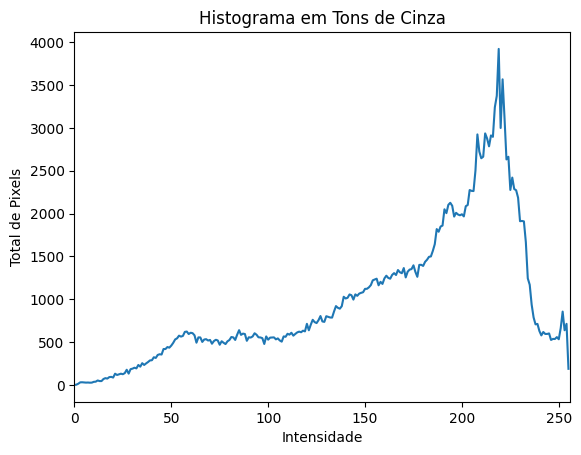

/tmp/ipykernel_54778/1021119588.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.ravel(),256,[0,256])


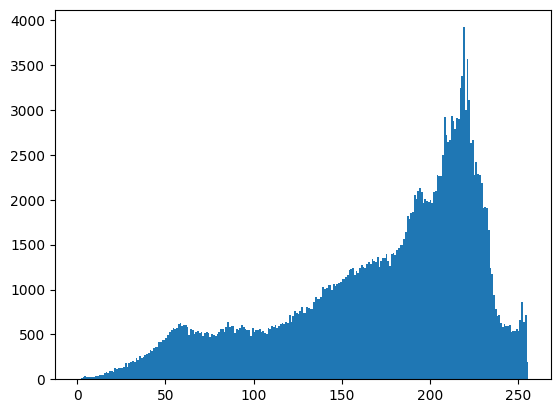

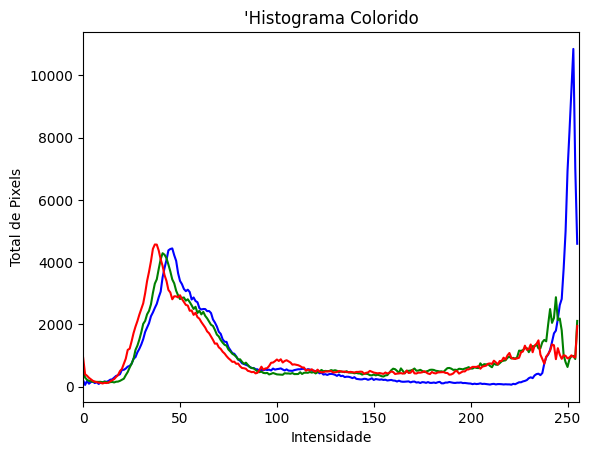

In [30]:
import matplotlib.pyplot as plt
image = cv2.imread('/home/guilherme/py_projects/computer-vision/data/dados_opencv/images/familia.jpg')


# Converte de RGB para Grayscale
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

# Calcula o histograma
hist = cv2.calcHist([image], [0], None, [256], [0, 256]) 

# Histograma
plt.figure() 
plt.title("Histograma em Tons de Cinza") 
plt.xlabel("Intensidade") 
plt.ylabel("Total de Pixels") 
plt.plot(hist) 
plt.xlim([0, 256]) 
plt.show() 
cv2.waitKey(0)

# Também é possível plotar o histograma de outra forma, com a ajuda da função "ravel()". 
# Neste caso o eixo X avança o valor 255 indo até 300, espaço que não existem pixels.
plt.hist(image.ravel(),256,[0,256]) 
plt.show()

# Além do histograma da imagem em tons de cinza é possível plotar um histograma da imagem colorida. 
# Neste caso teremos três linhas, uma para cada canal. 
# Note que a função "zip" cria uma lista de tuplas formada pelas união das listas passadas 
#Separa os canais
image = cv2.imread('/home/guilherme/py_projects/computer-vision/data/dados_opencv/images/estrada.jpg')
canais = cv2.split(image) 
cores = ("b", "g", "r") 

plt.figure() 
plt.title("'Histograma Colorido") 
plt.xlabel("Intensidade") 
plt.ylabel("Total de Pixels") 
for (canal, cor) in zip(canais, cores):
	# Este loop executa 3 vezes, uma para cada canal 
	hist = cv2.calcHist([canal], [0], None, [256], [0, 256]) 
	plt.plot(hist, color = cor) 
	plt.xlim([0, 256]) 
plt.show()


### histogram-equalization

/tmp/ipykernel_54778/2225815732.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.ravel(), 256, [0,256])


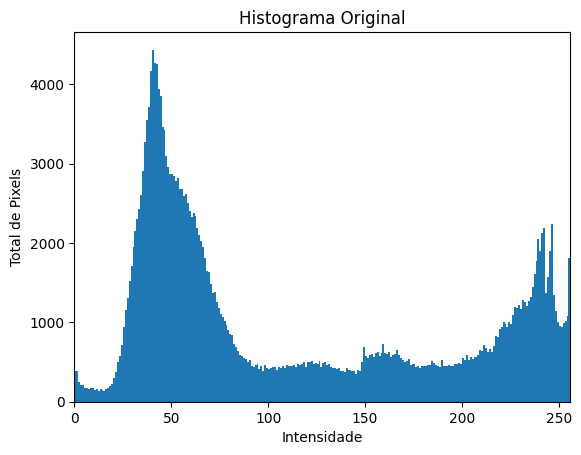

/tmp/ipykernel_54778/2225815732.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(h_eq.ravel(), 256, [0,256])


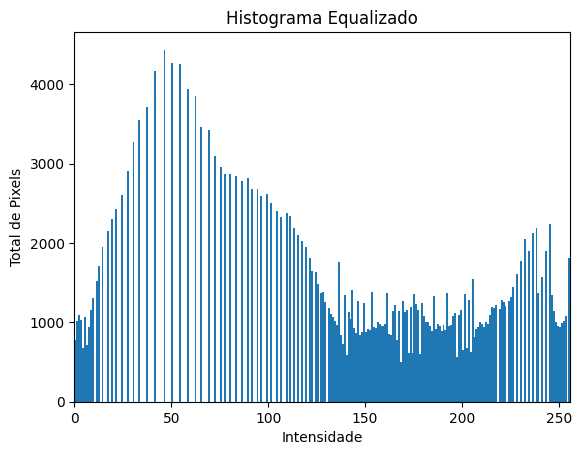

In [31]:
image = cv2.imread('/home/guilherme/py_projects/computer-vision/data/dados_opencv/images/familia.jpg')
image = cv2.imread('/home/guilherme/py_projects/computer-vision/data/dados_opencv/images/estrada.jpg')


# Converte de RGB para Grayscale
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

# Equalização do Histograma
h_eq = cv2.equalizeHist(image)

# Imagens
cv2.imshow("Original", image)
utils.imshow("Equalizada", h_eq)

# Histogramas

plt.figure()
plt.title("Histograma Original") 
plt.xlabel("Intensidade") 
plt.ylabel("Total de Pixels") 
plt.hist(image.ravel(), 256, [0,256]) 
plt.xlim([0, 256]) 
plt.show() 

plt.figure() 
plt.title("Histograma Equalizado") 
plt.xlabel("Intensidade") 
plt.ylabel("Total de Pixels") 
plt.hist(h_eq.ravel(), 256, [0,256]) 
plt.xlim([0, 256]) 
plt.show() 